In [51]:
import os
import math
import torch
from torch.nn.functional import softplus
from datetime import datetime
from tensorboardX import SummaryWriter
from equiv_dens.nn.neural_network_dens2 import NeuralNetwork
from equiv_dens.training.parse_command_line_arguments import parse_command_line_arguments
from equiv_dens.training.util import generate_id, empty_error_dict, compute_error_dict
from equiv_dens.training.density_dataset import AtomsDensityData
from equiv_dens.training.hamiltonian_dataset import seeded_random_split
from equiv_dens.training.exponential_moving_average import ExponentialMovingAverage
from equiv_dens.training.lookahead import Lookahead
from equiv_dens.training.batch_loader import BatchLoader
from equiv_dens.nn.modules.spherical_harmonics_expansion import SphericalHarmonicsExpansion

import numpy as np
import time
from functools import partial
from equiv_dens.training.grids import cubical_grid, cubical_sampling
from equiv_dens.nn.density_functionals.LDA import LDAFunctional

from dftpy.field import *
from dftpy.grid import *
from dftpy.functionals import FunctionalClass, TotalEnergyAndPotential
from dftpy.pseudo import LocalPseudo
from dftpy.formats import io, ase_io
from dftpy.math_utils import bestFFTsize
from dftpy.time_data import TimeData
from dftpy.optimization import Optimization
from dftpy.constants import LEN_CONV, ENERGY_CONV
from dftpy.system import System
import ase.io
import ml_dft.dft_utils as du
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
#directory = '2020-08-20_LuCuJBCl'  # load directory name
#model_name = 'LuCuJBCl'
# sq model
# directory = '2020-09-23_gtvoM9WL'  # load directory name
# model_name = 'gtvoM9WL'
# balance 1
# directory = '2020-09-28_YxazEPiG'  # load directory name
# model_name = 'YxazEPiG'
# balance 2
# directory = '2020-11-25_on882Qq5'  # load directory name
# model_name = 'on882Qq5'
# sp no integral model
# directory = '2020-11-24_twjvvsD8/'  # load directory name
# model_name = 'twjvvsD8'
# sp integral model
directory = '2020-11-25_vO2qku3v/'  # load directory name
model_name = 'vO2qku3v'

#directory = '2020-04-30_To0wdEze'
checkpoint_dir = os.path.join(
    directory, 'checkpoints')  # checkpoint directory
# load latest checkpoint
checkpoint = torch.load(os.path.join(
    checkpoint_dir, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['epoch']
ID = checkpoint['ID']  # load ID
args = checkpoint['args']  # overwrite args
args.use_gpu = False
args.load_from = os.path.join(directory, 'best_' + model_name + '.pth')

In [82]:
use_gpu = args.use_gpu and torch.cuda.is_available()

# load dataset(s)
print("loading density from" + args.dens_dataset + "...")
print("loading atoms from" + args.np_dataset + "...")

# density_file = '/home/mihail/data/water_rot/full_densities.hdf5'
# np_file = 'h2o_overlap_static.npy'

#args.num_workers = 0
#args.dens_dataset = 'datasets/h2o_dynamic_pyscf_dft_f_en.npy'
cube_dim = 50

cube_grid_fn = partial(cubical_grid, nx=cube_dim, ny=cube_dim, nz=cube_dim,
                       extent=np.array([4.1483, 4.1483, 4.1483]),
                       origin=np.array([-2.0318, -2.0318 , -2.0318]))
cube_sampling_fn = cubical_sampling

valid_cube_dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                                      orbitals_path=args.orbitals_file,
                                      density_n_samp=10000000000,
                                      required_properties=['density'],
                                      center_positions=False,
                                      radial_coeffs_file=args.radial_coeffs_file,
                                      dtype=args.dtype,
                                      grid_fn=cube_grid_fn,
                                      sampling_fn=cube_sampling_fn)

loading density fromdatasets/h2o_dynamic_pyscf_dft.npy...
loading atoms fromdatasets/h2o_dynamic_centered.npy...
Starting atomsdata density init
Some variables
atoms keys dict_keys(['positions', 'energy', 'forces', 'full_hamiltonian', 'overlap_matrix', 'core_hamiltonian', 'atom_types', 'atom_numbers'])
finished init


In [83]:
loss_weights = {}
loss_weights['density'] = args.density_weight
loss_weights['energy'] = args.energy_weight

valid_cube_sampler = torch.utils.data.BatchSampler(torch.utils.data.RandomSampler(valid_cube_dataset),
                                                   batch_size=args.valid_batch_size, drop_last=False)
valid_cube_loader = BatchLoader(valid_cube_dataset, batch_sampler=valid_cube_sampler,
                                num_workers=args.num_workers, pin_memory=use_gpu)


In [84]:
cube_iterator = iter(valid_cube_loader)

In [85]:
# define model
if args.load_from is None:
    equiv_model = NeuralNetwork(
        orbitals=dataset.orbitals,
        order=args.order,
        num_features=args.num_features,
        num_basis_functions=args.num_basis_functions,
        num_modules=args.num_modules,
        num_residual_pre_x=args.num_residual_pre_x,
        num_residual_post_x=args.num_residual_post_x,
        num_residual_pre_vi=args.num_residual_pre_vi,
        num_residual_pre_vj=args.num_residual_pre_vj,
        num_residual_post_v=args.num_residual_post_v,
        num_residual_output=args.num_residual_output,
        num_radial_components=args.num_radial_components,
        basis_functions=args.basis_functions,
        cutoff=args.cutoff,
        activation=args.activation)
    expansion_model = SphericalHarmonicsExpansion(valid_cube_dataset.orbitals,
                                                  radial_coeffs=valid_cube_dataset.radial_coeffs)
else:
    equiv_model = NeuralNetwork(load_from=args.load_from)
    expansion_model = SphericalHarmonicsExpansion(valid_cube_dataset.orbitals, radial_coeffs=valid_cube_dataset.radial_coeffs, expansion_constraint=args.expansion_constraint, integral_constraint=args.integral_constraint)

    

# convert the model to the correct dtype
equiv_model.to(args.dtype)
expansion_model.to(args.dtype)

# send model to GPU (if use_gpu is True)
if use_gpu:
    equiv_model.cuda()
    expansion_model.cuda()

print('weights balancing', args.weights_balance)

saved state dict_keys(['state_dict', 'orbitals', 'order', 'num_features', 'num_basis_functions', 'num_radial_components', 'num_modules', 'num_residual_pre_x', 'num_residual_post_x', 'num_residual_pre_vi', 'num_residual_pre_vj', 'num_residual_post_v', 'num_residual_output', 'basis_functions', 'cutoff', 'activation', 'Zmax'])
An orbital with L=5 was found, but the neural network was initialized with L=6
The neural network SHOULD have at least twice the order of the maximum order orbital for good results!
orbital_spec [[(8, 11, 0), (8, 8, 1), (8, 6, 2), (8, 4, 3), (8, 3, 4), (8, 2, 5)], [(1, 5, 0), (1, 4, 1), (1, 4, 2), (1, 3, 3), (1, 2, 4)], [(1, 5, 0), (1, 4, 1), (1, 4, 2), (1, 3, 3), (1, 2, 4)]]
cg_matrix shape torch.Size([121, 121, 121])
L_counts [16, 12, 10, 7, 5, 2, 0, 0, 0, 0, 0, 0, 0]
L_dict {(8, 0): range(0, 11), (8, 1): range(0, 8), (8, 2): range(0, 6), (8, 3): range(0, 4), (8, 4): range(0, 3), (8, 5): range(0, 2), (1, 0): range(11, 16), (1, 1): range(8, 12), (1, 2): range(6, 10

In [86]:
equiv_module = equiv_model
expansion_module = expansion_model

# for keeping an exponential moving average of the model parameters (usually leads to better models)
if checkpoint is not None:  # no checkpoint is specified
    step = checkpoint['step']
    epoch = checkpoint['epoch']
    best_errors = checkpoint['best_errors']
    valid_errors = checkpoint['valid_errors']
    equiv_module.load_state_dict(checkpoint['model_state_dict'])
# or initialize step / epoch to 0 and errors to infinity
else:
    step = 0
    epoch = 0
    best_errors = empty_error_dict(loss_weights, fill_value=math.inf)
    valid_errors = empty_error_dict(loss_weights, fill_value=math.inf)



In [87]:
print('best errors', best_errors)
print('valid_errors', valid_errors)

best errors {'loss': 0.00011338949934724953, 'density_mae': 2.8444238751035303e-05, 'density_rmse': 8.494526082358789e-05}
valid_errors {'loss': 0.00011396115405659657, 'density_mae': 2.8409765945980325e-05, 'density_rmse': 8.555138902011093e-05}


<IPython.core.display.Javascript object>


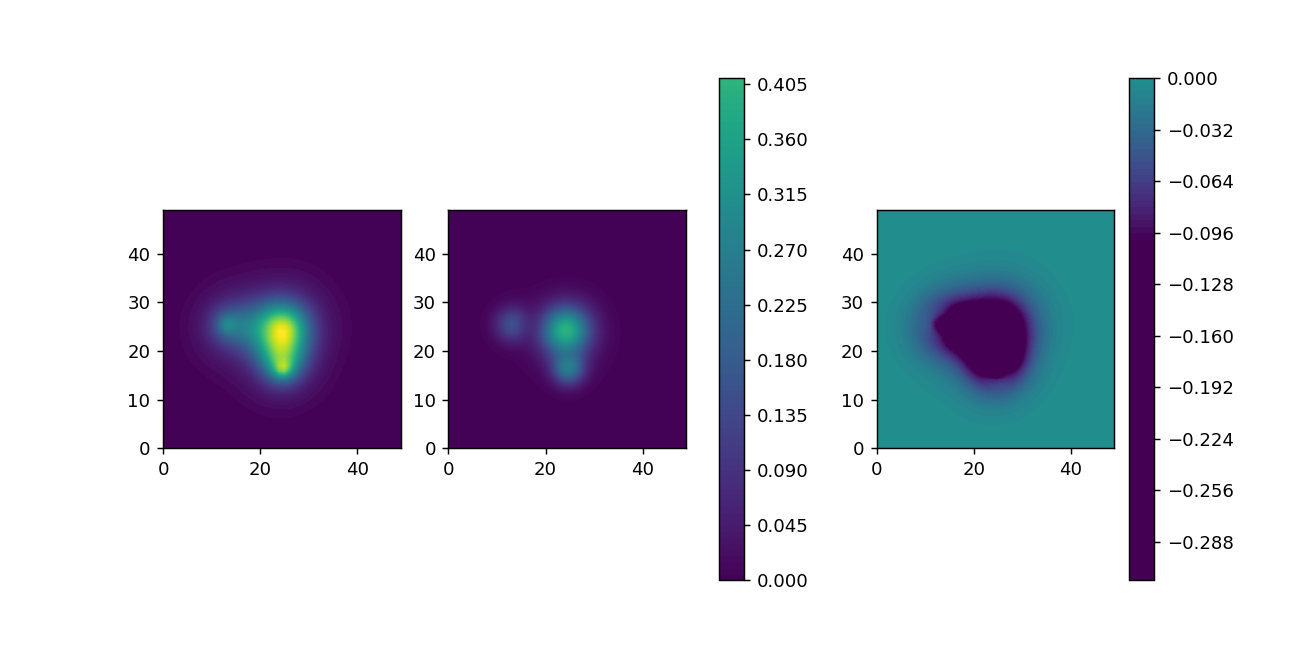

dens shape (125000,)
idx [    19   2519   5019 ... 119969 122469 124969]
coords space shape torch.Size([1, 125000, 3])
pos shape torch.Size([1, 3, 3])
positions type torch.FloatTensor
torch.Size([1, 125000])


In [95]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib notebook
sample = 5
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(131)
dens = np.array(valid_cube_dataset[sample]['density'].squeeze())
print('dens shape', dens.shape)
x, y  = np.meshgrid(np.arange(cube_dim), np.arange(cube_dim))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 19
idx = np.ravel_multi_index((x_f, y_f, z_f), (cube_dim, cube_dim, cube_dim))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = dens[idx]
dens2d = dens2d.reshape(cube_dim, cube_dim)

indices = np.stack((x_f, y_f, z_f), axis=1)
coords_space = valid_cube_dataset[sample]['coords']
print('coords space shape', coords_space.shape)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

positions = valid_cube_dataset[sample]['positions']
if args.use_gpu:
    positions = positions.cuda()
    coords_space = coords_space.cuda()

print('pos shape', valid_cube_dataset[[sample]]['positions'].shape)
print('positions type', positions.type())
coeffs = equiv_model(R=positions)
pred_dens = expansion_model(coords_space, positions,
                            coeffs['spherical_coeffs'],
                            coeffs['radial_width'],
                            coeffs['radial_scale'])



print(pred_dens['density'].shape)

p_dens = pred_dens['density'].cpu().data.squeeze().numpy()
p_dens = p_dens[idx].reshape(cube_dim, cube_dim)

ax2 = fig.add_subplot(132)
c2 = ax2.contourf(x, y, p_dens, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, p_dens-dens2d, vmin=-0.1, vmax=0.1, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2])
fig.colorbar(c3, ax=[ax3])
plt.show()

In [96]:
sample=5
pos = valid_cube_dataset[sample]['positions']
print('positions', pos)
coords = valid_cube_dataset[sample]['coords']
weights = valid_cube_dataset[sample]['coord_weights']
print('weights', weights)
print('coords shape', coords.shape)
dens_true = valid_cube_dataset[sample]['density']
print('density.shape', dens_true.shape)
print('density_integral', torch.sum(dens_true * weights))
dens_true_integral = torch.sum(dens_true * weights)
coeffs = equiv_model(R=pos)
dens_pred = expansion_model(coords, pos,
                            coeffs['spherical_coeffs'],
                            coeffs['radial_width'],
                            coeffs['radial_scale'])
dens_pred = dens_pred['density']
dens_pred_integral = torch.sum(dens_pred * weights)
dens_diff_integral = torch.sum(torch.abs(dens_pred - dens_true) * weights)
print('density pred integral', dens_pred_integral)
print('density_difference integral', dens_diff_integral)
print('density integral ratio', dens_diff_integral/dens_true_integral)

positions tensor([[[ 0.0000,  0.0000,  0.0000],
         [-0.9271,  0.1267, -0.5001],
         [ 0.0622, -0.6538, -0.4586]]])
weights tensor([0.0039, 0.0039, 0.0039,  ..., 0.0039, 0.0039, 0.0039])
coords shape torch.Size([1, 125000, 3])
density.shape torch.Size([1, 125000])
density_integral tensor(10.0396)
density pred integral tensor(5.6800, grad_fn=<SumBackward0>)
density_difference integral tensor(4.4930, grad_fn=<SumBackward0>)
density integral ratio tensor(0.4475, grad_fn=<DivBackward0>)


In [97]:
def MakeGrid(metric,gap):
    nr = np.zeros(3, dtype = 'int32')
    for i in range(3):
        nr[i] = int(np.sqrt(metric[i, i])/gap)
    print('The initial grid size is ', nr)
    for i in range(3):
        nr[i] = bestFFTsize(nr[i])
    print('The final grid size is ', nr)
    grid = DirectGrid(lattice=lattice, nr=nr, units=None, full=False)
    return grid

def guess_rho(grid,ions):
    charge_total = 0.0
    zerosA = np.zeros(grid.nnr, dtype=float)
    rho_ini = DirectField(grid=grid, griddata_F=zerosA, rank=1)
    for i in range(ions.nat) :
        charge_total += ions.Zval[ions.labels[i]]
    rho_ini[:] = charge_total/ions.pos.cell.volume
    return rho_ini

In [101]:
data_dir = '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/datasets/'
data = np.load(data_dir + 'h2o_dynamic_centered.npy', allow_pickle=True).item()
npy_pos = data['positions'][:10]
print('pos shape', npy_pos.shape)
ase_pos = du.npy_to_ase(npy_pos, data['atom_types'])
ions_list = []
for a in ase_pos:
    a.set_cell([4.1483, 4.1483, 4.1483])
    a.set_positions(a.positions + 2.0318)
    ions_list.append(ase_io.ase2ions(a))
    
for ions in ions_list:
    print(ions)
    
    
lattice = ions.pos.cell.lattice
metric = np.dot(lattice.T, lattice)

gap = 0.155
grid = MakeGrid(metric,gap)

pos shape (10, 3, 3)
                Zval : {}
                 pos : [[3.83954554 3.83954554 3.83954554]
 [2.39058861 3.31648449 2.59976431]
 [4.27278604 5.13626056 3.06808945]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.83954554 3.83954554 3.83954554]
 [5.02264259 2.86565066 2.16994608]
 [4.84285408 4.88704531 4.92259664]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.83954554 3.83954554 3.83954554]
 [4.1394715  5.76416171 3.7850345 ]
 [1.89574311 4.71071299 3.97092307]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.83954554 3.83954554 3.83954554]
 [3.32722004 4.18055795 2.11651788]
 [2.92506177 5.35897234 3.51984358]]
                 nat : 3
                   Z : [8 1 1]
            

In [102]:
path_pp = '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/'
file_names = {'H': 'H.pbe-kjpaw_psl.0.1.UPF', 'C': 'C.pbe-kjpaw_psl.0.1.UPF',
             'O': 'O.pbe-n-kjpaw_psl.0.1.UPF'}
PP_list = {key: path_pp+file_names[key] for key in file_names.keys()}
print(PP_list)
PSEUDO = LocalPseudo(grid = grid, ions=None, PP_list=PP_list,PME=True)

{'H': '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/H.pbe-kjpaw_psl.0.1.UPF', 'C': '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/C.pbe-kjpaw_psl.0.1.UPF', 'O': '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/O.pbe-n-kjpaw_psl.0.1.UPF'}
setting key: H
setting key: C
setting key: O


torch.Size([50, 50, 50])


<IPython.core.display.Javascript object>


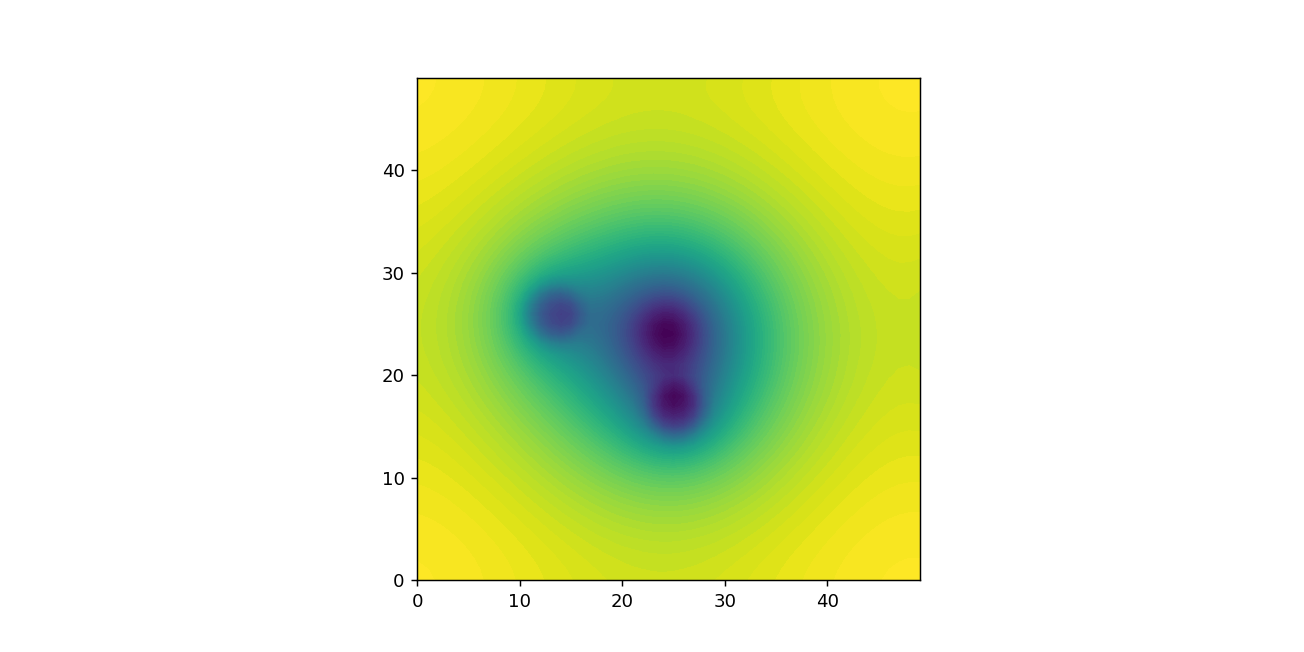

pseudo shape (125000,)
idx [    19   2519   5019 ... 119969 122469 124969]


In [104]:
from equiv_dens.training.grids import CubicalGrid
sample = 5
PSEUDO.restart(grid=grid, ions=ions_list[sample])
dens = valid_cube_dataset[sample]['density'].view([cube_dim, cube_dim, cube_dim])
grid_cl = CubicalGrid(None, nx=cube_dim, ny=cube_dim, nz=cube_dim, origin=[0, 0, 0], extent=np.diag(grid.lattice), device=dens.device, dtype=dens.type())
print(dens.shape)
PSEUDO(dens.detach().numpy())
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
pot = np.array(PSEUDO.vreal)
pot = pot.reshape((cube_dim**3, ))
print('pseudo shape', pot.shape)
x, y  = np.meshgrid(np.arange(cube_dim), np.arange(cube_dim))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 19
idx = np.ravel_multi_index((x_f, y_f, z_f), (cube_dim, cube_dim, cube_dim))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
pot2d = pot[idx]
pot2d = pot2d.reshape(cube_dim, cube_dim)

indices = np.stack((x_f, y_f, z_f), axis=1)
vmin = np.min(pot2d)
vmax = np.max(pot2d)
c1 = ax1.contourf(x, y, pot2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

In [105]:
ions = ions_list[sample]

z_vals = []
for t in data['atom_types']:
    z_vals.append(ions.Zval[t])
z_vals = np.array(z_vals)
print(data['atom_numbers'])
print(z_vals)
lda = LDAFunctional(z_vals)

pos = torch.tensor(ions.pos).to(dens)
PSEUDO.restart(grid=grid, ions=ions)
print('pos type', pos.type())
en = lda(dens, grid_cl, pos, PSEUDO)
print(en)

[8 1 1]
[6. 1. 1.]
pos type torch.FloatTensor
tensor(283.3147)


In [106]:
print('itegral = ', torch.sum(dens) * grid.dV)

itegral =  tensor(10.0396)


In [107]:
optional_kwargs = {}
KE = FunctionalClass(type='KEDF',name='x_TF_y_vW',optional_kwargs=optional_kwargs)
XC = FunctionalClass(type='XC',name='LDA')
HARTREE = FunctionalClass(type='HARTREE')

In [108]:
E_v_Evaluator = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=PSEUDO)

In [109]:
rho_data = guess_rho(grid, ions_list[sample])
rho_data[:] = dens.detach().numpy()
Enew = E_v_Evaluator.Energy(rho=rho_data, ions=ions, usePME = True)
print(Enew)

Ewald : -4.017185703380971
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 313.43008341551456
evalfunctional XC
evalfunctional LDA
energy -12.25646082545592
evalfunctional HARTREE
evalfunctional HARTREE
energy 42.912484542496315
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -56.7530102090941
283.3159112200799


In [110]:
print(valid_cube_dataset[sample]['positions'])

tensor([[[ 0.0000,  0.0000,  0.0000],
         [-0.9271,  0.1267, -0.5001],
         [ 0.0622, -0.6538, -0.4586]]])


In [112]:
optimization_options = {\
        'econv' : 1e-6, # Energy Convergence (a.u./atom)
        'maxfun' : 50,  # For TN method, it's the max steps for searching direction
        'maxiter' : 100,# The max steps for optimization
        }
optimization_options["econv"] *= ions.nat
opt = Optimization(EnergyEvaluator=E_v_Evaluator, optimization_options = optimization_options,
        optimization_method = 'TN')


rho_ini = guess_rho(grid, ions_list[sample])
new_rho = opt.optimize_rho(guess_rho=rho_ini)

evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.495135381679092
evalfunctional XC
evalfunctional LDA
energy -1.8371596242786297
evalfunctional HARTREE
evalfunctional HARTREE
energy 9.812258905963942e-34
evalfunctional PSEUDO
evalfunctional PSEUDO
energy 0.058245823674766335
Step    Energy(a.u.)            dE              dP              Nd      Nls     Time(s)         
0       -2.837784189248E-01     -2.837784E-01   7.655557E+00    1       1       7.394814E-02    
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
!WARN: Change to steepest decent
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.6071481852458809
evalfunctional XC
evalfunctional LDA
energy -1.8547297564456549
evalfunctional HARTREE
evalfunctional HARTREE
energy 0.048184134560637706
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -1.8329308171375331
evalfunctional KEDF
evalfunctional x_TF_

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctiona

evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalf

evalfunctional HARTREE
evalfunctional HARTREE
energy 6.555361866852695
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.793390429689925
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 10.25086229497574
evalfunctional XC
evalfunctional LDA
energy -3.350767676233555
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.602847268301745
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.879718476052755
9       -1.137677658901E+01     -9.825728E-04   3.256355E-03    21      2       1.185752E+01    
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional

evalfunctional XC
evalfunctional LDA
energy -3.345196842348645
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.575577721075877
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.818084106339096
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 10.207813257463377
evalfunctional XC
evalfunctional LDA
energy -3.344756208168558
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.573418636121372
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.81341644641795
12      -1.137694076100E+01     -1.866991E-05   6.380703E-05    14      2       1.546782E+01    
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional L

(50, 50, 50)

<IPython.core.display.Javascript object>


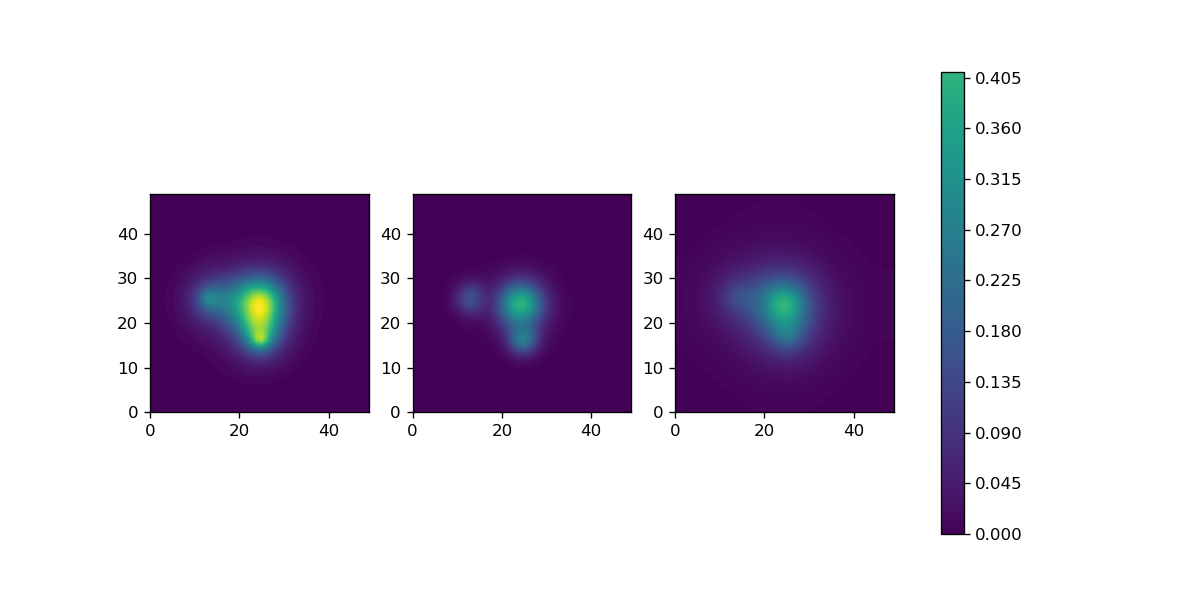

dens shape (125000,)
idx [    19   2519   5019 ... 119969 122469 124969]
coords space shape torch.Size([1, 125000, 3])
pos shape torch.Size([1, 3, 3])
positions type torch.FloatTensor
torch.Size([1, 125000])
opt_dens shape (50, 50)


In [118]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib notebook
sample = 5
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(131)
dens = np.array(valid_cube_dataset[sample]['density'].squeeze())
print('dens shape', dens.shape)
x, y  = np.meshgrid(np.arange(cube_dim), np.arange(cube_dim))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 19
idx = np.ravel_multi_index((x_f, y_f, z_f), (cube_dim, cube_dim, cube_dim))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = dens[idx]
dens2d = dens2d.reshape(cube_dim, cube_dim)

indices = np.stack((x_f, y_f, z_f), axis=1)
coords_space = valid_cube_dataset[sample]['coords']
print('coords space shape', coords_space.shape)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

positions = valid_cube_dataset[sample]['positions']
if args.use_gpu:
    positions = positions.cuda()
    coords_space = coords_space.cuda()

print('pos shape', valid_cube_dataset[[sample]]['positions'].shape)
print('positions type', positions.type())
coeffs = equiv_model(R=positions)
pred_dens = expansion_model(coords_space, positions,
                            coeffs['spherical_coeffs'],
                            coeffs['radial_width'],
                            coeffs['radial_scale'])



print(pred_dens['density'].shape)

p_dens = pred_dens['density'].cpu().data.squeeze().numpy()
p_dens = p_dens[idx].reshape(cube_dim, cube_dim)

ax2 = fig.add_subplot(132)
c2 = ax2.contourf(x, y, p_dens, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')
print('opt_dens shape', opt_dens.shape)
opt_dens = np.array(new_rho.reshape(-1)[idx].reshape(cube_dim, cube_dim))

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, opt_dens, vmin=vmin, vmax=vmax, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2, ax3])

plt.show()